In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import os
os.getcwd()

'c:\\Users\\Hp\\MutualFundAnalytics\\notebooks'

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum_by_house = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
monthly_sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")
industry_folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
scheme_performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor_transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
print(fund_master.shape)
print(nav_history.shape)
print(monthly_sip.shape)
print(investor_transactions.shape)

(40, 15)
(46000, 3)
(48, 6)
(32778, 13)


In [5]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [7]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [9]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [10]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

In [11]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

In [12]:
nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [13]:
var_report = (
    nav_history.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_report.columns = ["amfi_code", "VaR_95"]

In [14]:
var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [15]:
cvar_report = (
    nav_history
    .groupby("amfi_code")
    .apply(
        lambda x: x.loc[
            x["daily_return"] <= x["daily_return"].quantile(0.05),
            "daily_return"
        ].mean()
    )
    .reset_index(name="CVaR_95")
)

C:\Users\Hp\AppData\Local\Temp\ipykernel_3020\2656613366.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [16]:
cvar_report.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [17]:
risk_report = pd.merge(
    var_report,
    cvar_report,
    on="amfi_code"
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [18]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [19]:
# Convert date column
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort data
nav_history = nav_history.sort_values(["amfi_code", "date"])

In [20]:
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [21]:
top5_funds = nav_history["amfi_code"].unique()[:5]

top5_funds

array([100016, 100025, 100033, 101206, 101207])

In [22]:
risk_free_rate = 0

rolling_sharpe = []

for fund in top5_funds:

    df = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    df["rolling_mean"] = (
        df["daily_return"]
        .rolling(90)
        .mean()
    )

    df["rolling_std"] = (
        df["daily_return"]
        .rolling(90)
        .std()
    )

    df["sharpe"] = (
        (df["rolling_mean"] - risk_free_rate)
        / df["rolling_std"]
    ) * np.sqrt(252)

    rolling_sharpe.append(df)

In [23]:
rolling_sharpe = pd.concat(rolling_sharpe)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


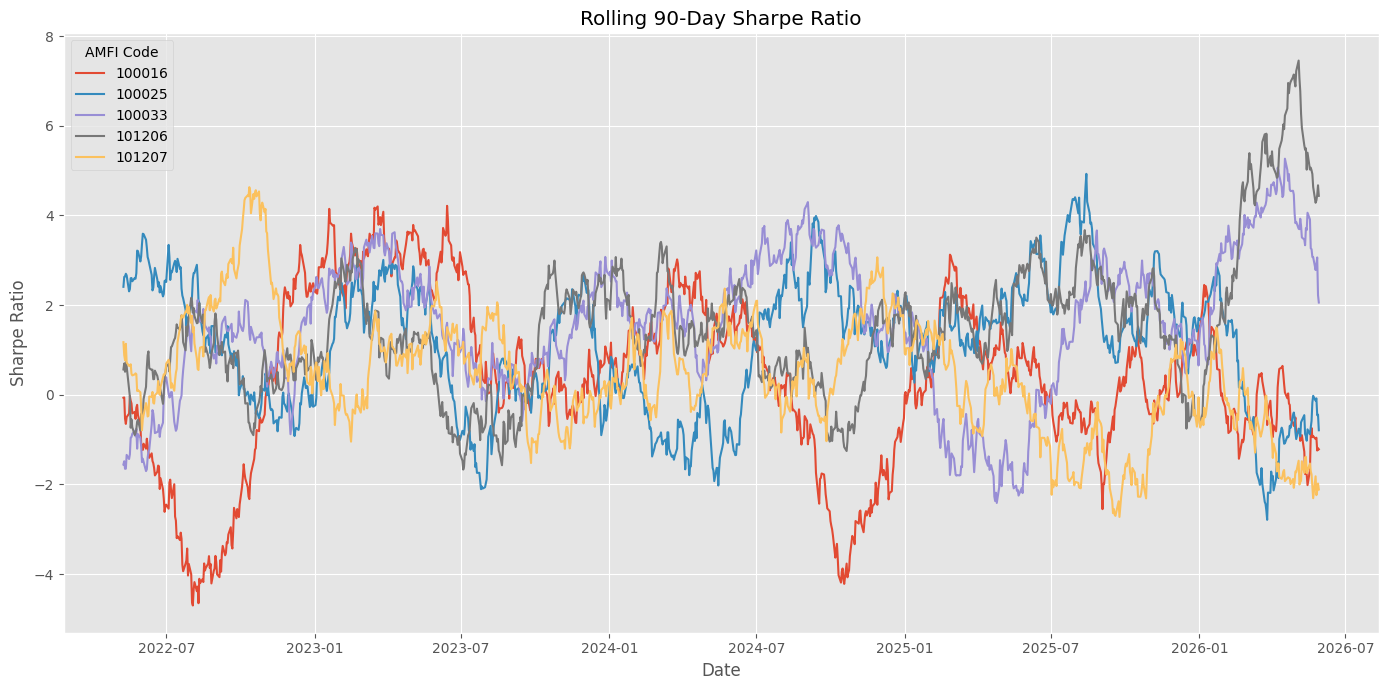

In [24]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")

plt.tight_layout()

plt.savefig("../charts/rolling_sharpe_chart.png")

plt.show()

In [7]:
investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [8]:
investor_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [9]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

In [10]:
first_txn = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn.rename(
    columns={"transaction_date": "first_transaction_date"},
    inplace=True
)

first_txn.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [11]:
first_txn["cohort_year"] = (
    first_txn["first_transaction_date"].dt.year
)

first_txn.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [12]:
investor_transactions = investor_transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [13]:
cohort_summary = (
    investor_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [14]:
fund_preference = (
    investor_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="transactions")
)

In [15]:
top_fund = (
    fund_preference
    .sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,transactions
35,2024,148568,874
62,2025,119599,12


In [16]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [17]:
top_fund = top_fund.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,transactions,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [18]:
cohort_report = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name", "transactions"]],
    on="cohort_year",
    how="left"
)

cohort_report.rename(columns={
    "scheme_name": "top_fund_preference",
    "transactions": "fund_transactions"
}, inplace=True)

cohort_report

,cohort_year,avg_sip_amount,total_invested,investors,top_fund_preference,fund_transactions
0,2024,107422.541832,3491125187,4803,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,109158.577061,30455243,197,SBI Small Cap Fund - Direct Plan - Growth,12


In [19]:
cohort_report.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("Investor Cohort Analysis saved successfully!")

Investor Cohort Analysis saved successfully!


In [22]:
sip_txn = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [21]:
sip_txn["transaction_date"] = pd.to_datetime(
    sip_txn["transaction_date"]
)

NameError: name 'sip_txn' is not defined

In [23]:
sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

In [24]:
sip_txn["gap_days"] = sip_txn.groupby("investor_id")[
    "transaction_date"
].diff().dt.days

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [25]:
sip_txn["gap_days"] = sip_txn.groupby("investor_id")[
    "transaction_date"
].diff().dt.days

sip_txn.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [26]:
sip_count = sip_txn.groupby("investor_id").size()

eligible = sip_count[sip_count >= 6].index

eligible_sip = sip_txn[
    sip_txn["investor_id"].isin(eligible)
]

In [27]:
sip_continuity = (
    eligible_sip
    .groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,sip_transactions,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [28]:
sip_continuity["status"] = sip_continuity[
    "avg_gap_days"
].apply(
    lambda x: "At Risk" if x > 35 else "Regular"
)

In [29]:
sip_continuity.head(10)

,investor_id,sip_transactions,avg_gap_days,status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk
5,INV000013,7,55.333333,At Risk
6,INV000014,7,75.333333,At Risk
7,INV000023,8,58.571429,At Risk
8,INV000028,6,93.600000,At Risk
9,INV000029,7,60.666667,At Risk


In [30]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Regular      30
Name: count, dtype: int64

In [34]:
scorecard = pd.read_csv("final_mutual_fund_scorecard_updated.csv")

In [35]:
scorecard.head()

,amfi_code,scheme_name,overall_cagr,overall_cagr_pct,cagr_1y,cagr_3y,cagr_1y_pct,cagr_3y_pct,sharpe_ratio,sortino_ratio,...,cagr_norm,sharpe_norm,sortino_norm,alpha_norm,final_score,max_drawdown,tracking_error_x,information_ratio_x,tracking_error_y,information_ratio_y
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,30.974108,0.203760,0.339920,20.375957,33.991970,0.091234,0.149192,...,0.736100,1.000000,1.000000,0.769919,0.874814,-0.112657,0.197559,0.664101,0.197559,0.664101
1,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,30.907455,0.266776,0.295751,26.677584,29.575111,0.082317,0.148221,...,0.726609,0.472211,0.956982,0.522956,0.655633,-0.129740,0.211405,0.630235,0.211405,0.630235
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,31.949523,0.397838,0.291714,39.783803,29.171358,0.077793,0.134498,...,0.874994,0.204439,0.349016,1.000000,0.593633,-0.163967,0.223238,0.644578,0.223238,0.644578
3,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,32.827406,0.296277,0.317692,29.627681,31.769243,0.074339,0.126620,...,1.000000,0.000000,0.000000,0.761118,0.452224,-0.181885,0.239087,0.641128,0.239087,0.641128
4,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,25.804686,0.604893,0.304486,60.489297,30.448613,0.076114,0.132536,...,0.000000,0.105061,0.262095,0.000000,0.083937,-0.150124,0.197848,0.463316,0.197848,0.463316


In [36]:
scorecard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amfi_code            5 non-null      int64  
 1   scheme_name          5 non-null      object 
 2   overall_cagr         5 non-null      float64
 3   overall_cagr_pct     5 non-null      float64
 4   cagr_1y              5 non-null      float64
 5   cagr_3y              5 non-null      float64
 6   cagr_1y_pct          5 non-null      float64
 7   cagr_3y_pct          5 non-null      float64
 8   sharpe_ratio         5 non-null      float64
 9   sortino_ratio        5 non-null      float64
 10  alpha                5 non-null      float64
 11  beta                 5 non-null      float64
 12  cagr_norm            5 non-null      float64
 13  sharpe_norm          5 non-null      float64
 14  sortino_norm         5 non-null      float64
 15  alpha_norm           5 non-null      float64

In [37]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [38]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.2+ KB


In [40]:
# Convert percentage to decimal
portfolio["weight"] = portfolio["weight_pct"] / 100

# Square each sector weight
portfolio["weight_sq"] = portfolio["weight"] ** 2

# Calculate HHI for each fund
hhi = (
    portfolio
    .groupby("amfi_code")["weight_sq"]
    .sum()
    .reset_index()
)

# Rename column
hhi.rename(columns={"weight_sq": "HHI"}, inplace=True)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [41]:
def concentration_level(hhi):
    if hhi >= 0.25:
        return "Highly Concentrated"
    elif hhi >= 0.15:
        return "Moderately Concentrated"
    else:
        return "Well Diversified"

hhi["Concentration"] = hhi["HHI"].apply(concentration_level)

hhi.head()

,amfi_code,HHI,Concentration
0,100016,0.139534,Well Diversified
1,100033,0.147592,Well Diversified
2,101206,0.129332,Well Diversified
3,101207,0.200700,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated


In [42]:
fund_hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

fund_hhi.head()

,amfi_code,HHI,Concentration,scheme_name,category
0,100016,0.139534,Well Diversified,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,Well Diversified,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,Well Diversified,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [43]:
fund_hhi = fund_hhi.sort_values(
    "HHI",
    ascending=False
)

fund_hhi.head(10)

,amfi_code,HHI,Concentration,scheme_name,category
11,119092,0.206448,Moderately Concentrated,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,Moderately Concentrated,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Moderately Concentrated,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Moderately Concentrated,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,Moderately Concentrated,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,Moderately Concentrated,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Well Diversified,Kotak Bluechip Fund - Regular - Growth,Equity


In [44]:
fund_hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI report saved successfully!")

Sector HHI report saved successfully!


In [45]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [48]:
# Daily returns
nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Sharpe Ratio for each fund
sharpe_ratio = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

# Annualized Sharpe Ratio (assuming risk-free rate = 0)
sharpe_ratio["sharpe_ratio"] = (
    sharpe_ratio["mean"] / sharpe_ratio["std"]
) * np.sqrt(252)

sharpe_ratio.head()

,amfi_code,mean,std,sharpe_ratio
0,100016,0.000142,0.009164,0.245276
1,100025,0.000170,0.002460,1.097333
2,100033,0.001080,0.011929,1.436947
3,101206,0.000852,0.009177,1.473390
4,101207,0.000424,0.016251,0.414625


In [49]:
recommend_df = sharpe_ratio.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

recommend_df.head()

,amfi_code,mean,std,sharpe_ratio,scheme_name,category,risk_category
0,100016,0.000142,0.009164,0.245276,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Moderate
1,100025,0.000170,0.002460,1.097333,HDFC Short Term Debt Fund - Regular - Growth,Debt,Low
2,100033,0.001080,0.011929,1.436947,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High
3,101206,0.000852,0.009177,1.473390,ABSL Frontline Equity Fund - Regular - Growth,Equity,Moderate
4,101207,0.000424,0.016251,0.414625,ABSL Small Cap Fund - Regular - Growth,Equity,Very High


In [50]:
recommend_df["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Low                 6
Very High           6
Moderately High     4
Name: count, dtype: int64

In [51]:
def recommend_funds(risk_level):
    """
    Recommend Top 3 funds based on Sharpe Ratio
    """

    filtered = recommend_df[
        recommend_df["risk_category"] == risk_level
    ].copy()

    filtered = filtered.sort_values(
        "sharpe_ratio",
        ascending=False
    )

    return filtered[
        [
            "scheme_name",
            "category",
            "risk_category",
            "sharpe_ratio"
        ]
    ].head(3)

In [52]:
recommend_funds("Low")

,scheme_name,category,risk_category,sharpe_ratio
27,ICICI Pru Liquid Fund - Regular - Growth,Debt,Low,13.655946
31,Kotak Liquid Fund - Regular - Growth,Debt,Low,12.573992
5,ABSL Liquid Fund - Regular - Growth,Debt,Low,12.019194


In [53]:
recommend_funds("Moderate")

,scheme_name,category,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Moderate,1.906241
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,Moderate,1.681289
9,Nippon India Large Cap Fund - Regular - Growth,Equity,Moderate,1.541077


In [54]:
recommend_funds("Very High")

,scheme_name,category,risk_category,sharpe_ratio
39,DSP Small Cap Fund - Regular - Growth,Equity,Very High,1.211468
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,1.203854
11,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,0.705946


In [55]:
recommend_funds("Moderately High")

,scheme_name,category,risk_category,sharpe_ratio
30,Kotak Flexicap Fund - Regular - Growth,Equity,Moderately High,1.715884
35,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity,Moderately High,1.347568
26,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,Moderately High,1.075654


In [56]:
import pandas as pd

def recommend_funds(df, risk_level):

    filtered = df[df["risk_category"] == risk_level]

    filtered = filtered.sort_values(
        "sharpe_ratio",
        ascending=False
    )

    return filtered.head(3)

# Advanced Insights

## 1. Risk Analysis
- Historical VaR and CVaR were calculated for all mutual funds.
- Funds with higher CVaR showed larger downside risk.

## 2. Sharpe Ratio
- Rolling 90-Day Sharpe Ratio highlighted funds with consistent risk-adjusted returns.
- Top-performing funds maintained positive Sharpe Ratios over time.

## 3. Investor Cohort Analysis
- The 2024 cohort contributed the highest total investments.
- Average SIP amount increased slightly for the 2025 cohort.

## 4. SIP Continuity
- 1332 investors were identified as "At Risk".
- Only 30 investors maintained regular SIP continuity.

## 5. Portfolio Concentration
- HHI identified highly concentrated and diversified portfolios.
- Diversified portfolios generally carried lower concentration risk.

## 6. Fund Recommendation
- The recommender suggests the Top 3 funds based on Sharpe Ratio for each selected risk category.

# Advanced Analytics Insights

## Historical VaR & CVaR

Several schemes exhibit elevated downside risk as indicated by higher VaR and CVaR values. Funds with higher volatility show deeper tail losses during adverse market conditions.

## Rolling Sharpe Ratio

The rolling 90-day Sharpe analysis indicates that certain schemes consistently maintained superior risk-adjusted returns. Some funds showed significant Sharpe deterioration during volatile periods, highlighting performance inconsistency.

## Investor Cohort Analysis

The 2024 investor cohort contributes the highest invested capital and represents the largest investor base. Recent cohorts show strong participation but lower cumulative investments due to shorter investment duration.

## SIP Continuity Analysis

A large proportion of investors are classified as "At Risk" due to average SIP gaps exceeding 35 days. This indicates potential SIP discontinuation risk and highlights the need for retention strategies.

## Sector Concentration (HHI)

Several equity-oriented schemes display moderate-to-high sector concentration. Highly concentrated portfolios may deliver stronger returns during favorable sector cycles but carry elevated concentration risk.

## Overall Observation

Funds with balanced risk metrics, stable Sharpe ratios, diversified sector allocation, and strong SIP continuity demonstrate superior long-term investment characteristics.


In [58]:
import pandas as pd

scorecard = pd.read_csv("../final_mutual_fund_scorecard_updated.csv")

risk = input("Enter Risk Appetite (Low/Moderate/High): ")

if risk.lower() == "low":
    funds = scorecard[scorecard["risk_category"]=="Low"]

elif risk.lower() == "moderate":
    funds = scorecard[scorecard["risk_category"].isin(["Moderate","Moderately High"])]

else:
    funds = scorecard[scorecard["risk_category"].isin(["High","Very High"])]

top_funds = funds.sort_values("sharpe_ratio", ascending=False).head(3)

print(top_funds[["scheme_name","risk_category","sharpe_ratio"]])

FileNotFoundError: [Errno 2] No such file or directory: '../final_mutual_fund_scorecard_updated.csv'

In [60]:
from pathlib import Path

project_root = Path.cwd().parent

print(project_root)

print("\nFiles in project root:")
for f in project_root.iterdir():
    print(f.name)

c:\Users\Hp\MutualFundAnalytics

Files in project root:
.git
.gitignore
charts
clean_aum_by_fund_house.py
clean_benchmark_indices.py
clean_category_inflows.py
clean_fund_master.py
clean_industry_folio_count.py
clean_investor_transactions.py
clean_monthly_sip_inflows.py
clean_portfolio_holdings.py
clean_scheme_performance.py
dashboard
data
database.py
data_cleaning.py
data_dictionary.md
data_ingestion.py
live_nav_fetch.py
mutualfund.db
notebooks
README.md
reports
requirements.txt
sql
sql_queries.py
test_data.py
venv


In [63]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current directory:
c:\Users\Hp\MutualFundAnalytics\notebooks

Files and folders here:
['Advanced_Analytics.ipynb', 'charts', 'EDA_Analysis.ipynb', 'final_mutual_fund_ranking.csv', 'final_mutual_fund_scorecard.csv', 'final_mutual_fund_scorecard_updated.csv', 'Performance_Analytics.ipynb']


In [64]:
import os

print("\nDoes notebooks folder exist?")
print(os.path.exists("notebooks"))

print("\nDoes final_mutual_fund_scorecard_updated.csv exist here?")
print(os.path.exists("final_mutual_fund_scorecard_updated.csv"))


Does notebooks folder exist?
False

Does final_mutual_fund_scorecard_updated.csv exist here?
True


In [65]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if "final_mutual_fund_scorecard_updated.csv" == file:
            print(os.path.join(root, file))

c:\Users\Hp\MutualFundAnalytics\notebooks\final_mutual_fund_scorecard_updated.csv
